# Code for plots in Fig.6

First we load libraries and modules

In [6]:
import numpy as np
import matplotlib as mpl
mpl.use("Qt5Agg")
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from statsmodels.stats.multitest import multipletests
import os, sys, inspect
from statsmodels.stats.anova import AnovaRM
from scipy.stats import stats,mannwhitneyu,ttest_ind,levene,shapiro, ttest_1samp, anderson, ttest_rel, wilcoxon
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd
from scipy.stats import friedmanchisquare,kruskal
from scipy.stats import norm
from scipy.stats import entropy
%matplotlib inline

# import modules
from pseudopopulation_intime import Single_var,Behavior
from pseudopopulation_geometry import Cross_var, By_window, By_window_decoder,\
    Window_cohort_neuronset,Window_cohort_decspace
from subject_decoding import Single_var_subject,Cross_var_subject,Window_subject,\
    Window_subject_decoder
from beh_corr_nrl import Bin_nrl_to_beh    

currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from data_import import Trial
from utilities import compute_pvalues_trace,plot_pvalues_trace,\
    normality_test,statistical_annotation,format_violinplot,sphericity_test,\
        null_two_conditions,compute_pvalues_trace_corrected,format_axs,\
            stats_two_independent,mass_above_threshold,bootstrap_pval,p_to_ast,\
            pvalue_bootstrap_corrected,volcano_plot,get_noise_vec,compute_ellipse,\
                pca_residual,compute_volume_tetrahedron,compute_orthogonalized_vector,\
                    compute_subspace_var_ratio,trainingpoint_dict

Please enter DataJoint username: root
Please enter DataJoint password: ········
Connecting root@localhost:3306
Calling validation_alignment.py from module script:  data_import.cell_registration
Calling cell_registration.py from module script:  data_import.cell_registration
Calling helper_data.py from module script:  utilities.helper_data
Calling helper_tensor.py from module script:  utilities.helper_tensor
Calling helper_logreg.py from module script:  utilities.helper_logreg
Calling helper_binreg.py from module script:  utilities.helper_binreg
Calling behaviour_import.py from module script:  data_import.behaviour_import
Calling recording_import.py from module script:  data_import.recording_import
Calling aligned_recording.py from module script:  data_import.aligned_recording
Calling dlc_video.py from module script:  data_import.dlc_video
Calling training.py from module script:  behaviour.training
Calling day_statistics.py from module script:  behaviour.day_statistics
Calling categories

In [13]:
%matplotlib inline

## Fig 6A
corresponds to schematic illustrations


## Fig 6B (& S5A)
### Cross-condition decoding in trial time for variables (category, choice, outcome) with all splits

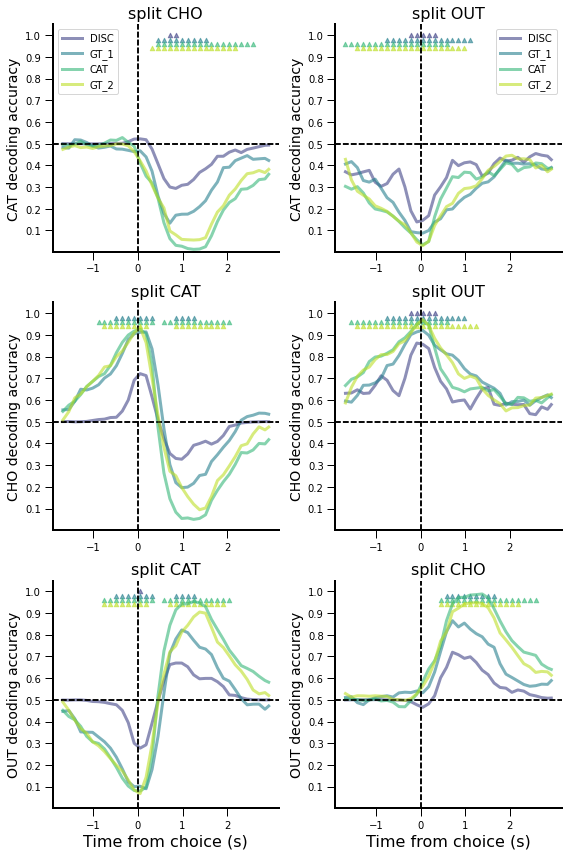

In [6]:
def pseudopop_geometry():
    '''
    panel with phases x variables for each alignment
    pseudopopulation 
    '''
    variables = ['category', 'choice', 'outcome']
    event_align = 'choice'
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    label_dict = {
        'discrimination':'DISC',
        'gentest_1':'GT_1',
        'categorization_4':'CAT',
        'gentest_2':'GT_2'}
    
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    
    fig,axs = plt.subplots(len(variables),len(variables)-1)
    fig.set_figwidth(4*(len(variables)-1))
    fig.set_figheight(4*len(variables))

    for i,v in enumerate(variables):
        cross_variables = variables.copy()
        cross_variables.pop(i)
        for phase in phases:
            color_idx = phases.index(phase)
            
            entry = Cross_var()\
                & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align
                    
            cross_acc_all = entry.fetch('cross_var_acc')[0]
            timepoints = entry.fetch('timepoints')[0]
            null_all = entry.fetch('cross_var_null')[0]
            assert cross_variables == entry.fetch('cross_variables')[0]
            
            for j,cross_v in enumerate(cross_variables):
                acc = np.mean(cross_acc_all[:,j],0)
                null = null_all[:,j]
                
                _,pvalues_acc = compute_pvalues_trace_corrected(acc,null,stat_type='two-sided') # two-sided
                
                
                axs[i,j].plot(timepoints,acc,color=colors[color_idx],linewidth=3,alpha=0.6,
                              label = label_dict[phase])
                axs[i,j] = plot_pvalues_trace(axs[i,j],pvalues_acc,timepoints,
                                        1-color_idx*0.02,colors[color_idx],alpha=0.6)
                
                axs[i,j].set_ylabel('%s decoding accuracy'%v[:3].upper(),fontsize=14)
                axs[i,j].axvline(x=0,linestyle='--',color='black',alpha=0.7)
                axs[i,j].axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
                axs[i,j].set_ylim(0,1.05)
                axs[i,j].set_yticks(np.arange(0.1,1.05,0.1))
                axs[i,j].set_xticks(np.arange(int(timepoints[0]),int(timepoints[-1])+0.5,1))
                axs[i,j].spines["top"].set_visible(False)
                axs[i,j].spines["right"].set_visible(False)
                axs[i,j].spines["bottom"].set_linewidth(2)
                axs[i,j].spines["left"].set_linewidth(2)
                axs[i,j].tick_params(size= 8,width=1, length=10) # labelsize = labelsize
                axs[i,j].set_title('split %s'%cross_v[:3].upper(),fontsize=16)
                if i == 0:
                    
                    axs[i,j].legend()
                elif i == len(variables)-1:
                    for ax in axs[i]:
                        ax.set_xlabel('Time from %s (s)'%event_align,fontsize=16)

        
    plt.tight_layout()
    plt.show()
    
pseudopop_geometry()

## Fig 6C
### Integrated cross-decoding accuracy overlap of $Cc-cho_{out}$ and $ Cc-out_{cho}$

Overall test:  Kruskall-Wallis test
p: 4.202000371707163e-61
pair comparisons tests
t test ind
DISC  vs  GT_1 True
t test ind
DISC  vs  CAT True
t test ind
DISC  vs  GT_2 True
t test ind
GT_1  vs  CAT True
t test ind
GT_1  vs  GT_2 True
t test ind
CAT  vs  GT_2 True


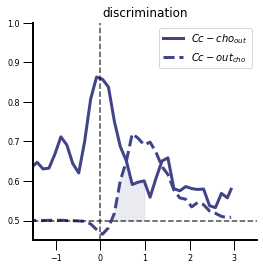

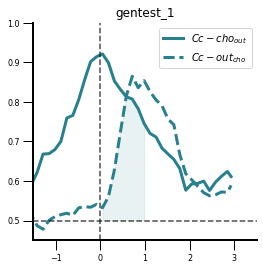

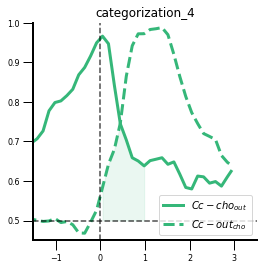

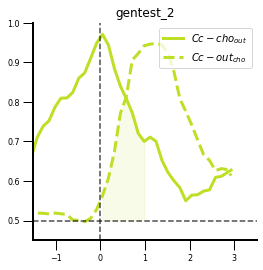

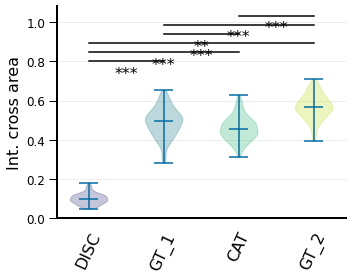

In [23]:
def integrated_crossdec_overlap(window_length=1):
    variables = ['choice','outcome']
    
    nr_crossval = 100
    column_labels = ['DISC', 'GT_1', 'CAT', 'GT_2']
    trace_labels = ['$Cc-cho_{out}$','$Cc-out_{cho}$']
    var_window = [0,window_length]
    
    event_align = 'choice'
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    nr_phases = len(phases)
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    data_auc = np.zeros((len(phases),nr_crossval)) 
    xvals = np.arange(0,len(phases),1)
    
    for j,phase in enumerate(phases):
        # plot overlap
        fig, axs = plt.subplots()
        fig.set_figheight(4)
        fig.set_figwidth(4)
        linestyles = ['-','--']
        axs.set_title(phase)
        phase_crosstraces = []
        mean_stagetraces = []
        for i,v in enumerate(variables):
            entry = Cross_var()\
                & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align
                    
            cross_acc_all = entry.fetch('cross_var_acc')[0]
            timepoints = entry.fetch('timepoints')[0]
            acc = cross_acc_all[:,1]
            
            # plot mean 
            axs.plot(timepoints,np.mean(acc,axis=0),
                     linewidth=3,color=colors[j],linestyle=linestyles[i],label=trace_labels[i])
            
            mean_stagetraces.append(np.mean(acc,axis=0))
            
            # take timepoints in the specified window
            t_idx = [np.where(timepoints>var_window[0])[0][0],
                      np.where(timepoints>var_window[1])[0][0]]
            
            # restrict to specified window and subtract random level
            traces = (acc[:,t_idx[0]:t_idx[1]] - 0.5).copy()
            traces[traces < 0] = 0
            phase_crosstraces.append(traces)
            
        # plot intersection area between the two
        min_trace = np.minimum(mean_stagetraces[0],mean_stagetraces[1])
        # consider only the window length analyzed
        min_trace[:t_idx[0]] = 0.5
        min_trace[t_idx[1]:] = 0.5
        
        baseline = np.repeat(0.5,len(min_trace))
        axs.fill_between(timepoints,baseline,min_trace,
                         where=(min_trace > baseline),
                         color=colors[j], alpha=0.1)
        axs.legend()
        # compute intersection area between two traces
        intersec_area = []
        for n in range(nr_crossval):
            #pick two traces, one of each var at random
            rd_idx1, rd_idx2 = np.random.randint(0,nr_crossval,2)
            trace_choice = phase_crosstraces[0][rd_idx1]
            trace_outcome = phase_crosstraces[1][rd_idx2]
            intersec = trace_choice * trace_outcome
            intersec_area.append(np.trapz(intersec))
                                 
        data_auc[j] = intersec_area
        
        # format plot
        axs.axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
        axs.axvline(x=0,linestyle='--',color='black',alpha=0.7)
        axs = format_axs(axs)
        axs.set_ylim(0.45,1)
        axs.set_xlim(-1.5,3.5)

    # check assumptions of anova  -> default to kruskal wallis test
    
    # levene test to check for homogeneity of variances
    homogeneity = True
    res = levene(data_auc[0],
               data_auc[1],
               data_auc[2],
               data_auc[3])
    if res.pvalue < 0.05:
        homogeneity = False
        
    test = 'One way Anova' # one factor stage, with four levels

    # check normality
    normality = True
    for j,phase in enumerate(phases):
        shapiro_test = shapiro(data_auc[j])
        
        if shapiro_test.pvalue < 0.05:
            normality = False
            break
        
    if normality and homogeneity:
        test = 'One way Anova test'
    else:
        test = 'Kruskall-Wallis test'
    
    print('Overall test: ',test)
    
    if normality and homogeneity:
        # one way anova
        res = stats.f_oneway(data_auc[0],
               data_auc[1],
               data_auc[2],
               data_auc[3])
        pval = res.pvalue
        
        # # transform data to pandas dataframe
        data = np.concatenate(data_auc)
        stage_col = np.repeat(np.arange(nr_phases), nr_crossval)
        data_df = np.vstack((data,stage_col)).T
        df = pd.DataFrame(data_df, columns=['auc', 'stage'])

        # check normality of residues of model
        model = ols('auc ~ C(stage)-1', data=df).fit()
        
        # model.pvalue,   model.model.exog_names
        _,resid_pval = shapiro(model.resid)
        #print('normality residue: ',resid_pval>0.05)
        
        
    else:
        # kruskal wallis
        res = stats.kruskal(data_auc[0],
               data_auc[1],
               data_auc[2],
               data_auc[3])
        pval = res.pvalue
        
    print('p: %s'%str(pval))
        
    # if signigicant check post hoc testing comparisons t test
    # with alpha bonferroni correction
    comparisons = []
    for j,phase in enumerate(phases):
        for k in range(j,len(phases)):
            if j!=k:
                comparisons.append([j,k])
    
        # color = np.repeat([colors[i]],3) 
    fig, axs = plt.subplots()
    fig.set_figheight(4)
    fig.set_figwidth(5)
    # nr samples x nr columns/conditions
    format_violinplot(axs,data_auc.T,column_labels,colors=colors)
    
    if pval < 0.05:
        # check all comparisons
        print('pair comparisons tests')
        comparison_pvals = []
        for c,comparison in enumerate(comparisons):
            col1,col2 = comparison
            
            if normality:
                stat,p_value = ttest_ind(data_auc[col1],data_auc[col2],
                                          alternative='two-sided')
                print('t test ind')
            else:
                stat,p_value = mannwhitneyu(data_auc[col1],data_auc[col2],
                                            alternative='two-sided')
                print('mann whitney u')
    
            print(column_labels[col1],' vs ',column_labels[col2],(p_value/len(comparisons))<0.05)
            comparison_pvals.append(p_value)
        
        ymax = data_auc.max(); ymin = data_auc.min()
        axs = statistical_annotation(axs,comparisons,
                                      comparison_pvals,ymax,ymin)
        
    axs.set_xticks(xvals)
    axs.set_xticklabels(column_labels,rotation=65, fontsize = 16)
    axs.spines["top"].set_visible(False)
    axs.spines["right"].set_visible(False)
    axs.spines["bottom"].set_linewidth(2)
    axs.spines["left"].set_linewidth(2)
    axs.tick_params(size= 8,width=1, length=10)
    axs.set_ylabel('Int. cross area',fontsize=16)
    plt.tight_layout()
    
integrated_crossdec_overlap()

## Fig 6D
### Cross-decoding accuracy computed on post-choice window ($Cc-cho_{out}$ and $ Cc-out_{cho}$) across stages

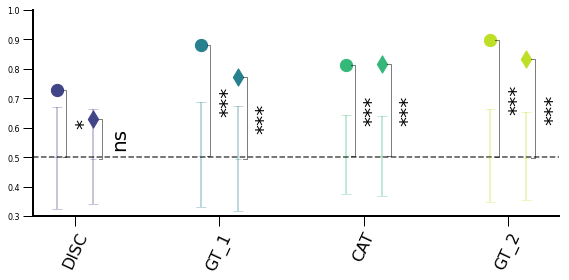

In [10]:
def pseudopop_geometry_window():
    variables = ['choice', 'outcome']
    event_align = 'choice'
    window = 'post_choice'
    window_length = 1
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    markers = ['o','d']
    label_dict = {
      'discrimination':'DISC',
      'gentest_1':'GT_1',
      'categorization_4':'CAT',
      'gentest_2':'GT_2'}
    
    column_labels = list(label_dict.values())
    x_ticks = np.arange(1,15,4)
    fig,axs = plt.subplots()
    fig.set_figwidth(8)
    fig.set_figheight(4)
    
    
    for i,phase in enumerate(phases):
        for j,v in enumerate(variables):
            entry = By_window()\
                   & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                       & 'event_align="%s"'%event_align \
                           & 'window="%s"'%window & 'window_length="%i"'%window_length
            # [1] for cross variable of choice - outcome, and for outcome - choice
            ccgp = np.mean(entry.fetch('ccgp')[0],0)[1] # nr crossvalidations x nr cross variables
            ccgp_null = np.array(entry.fetch('ccgp_null')[0])[:,1] # nr iters x nr cross variables
            m_null = np.mean(ccgp_null)
            
            axs.scatter(x_ticks[i]+j,ccgp,s=150,color=colors[i],marker=markers[j])
  
            # null distribution
            top = np.percentile(ccgp_null, 95) - m_null
            low = m_null - np.percentile(ccgp_null, 5)
            axs.errorbar(x_ticks[i]+j, [m_null], yerr=np.array([[low,top]]).T,
                                color=colors[i],linewidth=2, capsize=5, marker='_', alpha=0.3)
               
            # plot significance
            pvalue = bootstrap_pval(ccgp,ccgp_null,stat_type='one-side larger')
            axs.plot([x_ticks[i]+j + 0.15, x_ticks[i]+j + 0.25, x_ticks[i]+j + 0.25, x_ticks[i]+j + 0.15],
                            [m_null, m_null, ccgp, ccgp],
                            color='k', alpha=0.5, linewidth=1.0)
            axs.text(x_ticks[i]+j + 1, 0.5 * (m_null + ccgp), p_to_ast(pvalue), rotation=90,
                    ha='right', va='center', fontsize=20)
            
    axs.set_xticks(x_ticks+0.5)
    axs.axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
    axs = format_axs(axs)
    axs.set_ylim(0.3,1)
    axs.set_xticklabels(column_labels,rotation=65, fontsize = 16)
    
    plt.tight_layout()
    plt.show()
    
pseudopop_geometry_window()

## Fig 6E
### Population activity (color coded by trial type) in the post-choice window projected onto 2d plane given by decoding dimension for Choice and Outcome

phase:  discrimination
accuracy:  [0.91732615 0.73367872]
ccgp:  [0.72383345 0.63171766]
phase:  gentest_1
accuracy:  [0.94790334 0.90059805]
ccgp:  [0.86494263 0.77904381]
phase:  categorization_4
accuracy:  [0.96415508 0.96815021]
ccgp:  [0.83085362 0.80917246]
phase:  gentest_2
accuracy:  [0.96259736 0.95913421]
ccgp:  [0.89486787 0.84430459]


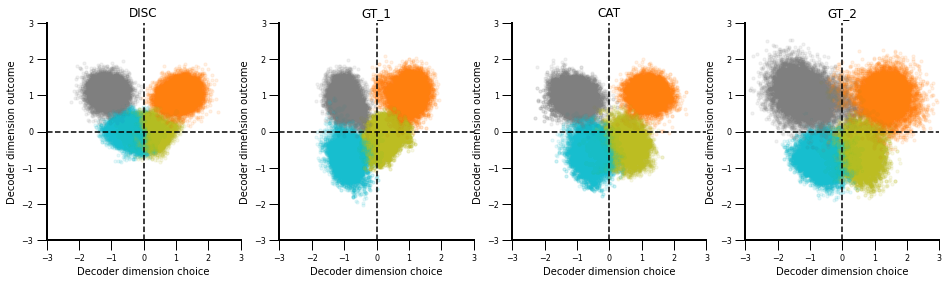

In [11]:
def neuralproj_dec_2d(window_length=1):
    colors_dict = {'BL':'tab:cyan',
                   'AR':'tab:olive',
                   'AL':'tab:gray',
                   'BR':'tab:orange'}
    
    state_combinations = {(1, 0, 0):'BL',
                   (0, 1, 0):'AR',
                   (0, 0, 1):'AL',
                   (1, 1, 1):'BR'}
    
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    phase_labels = ['DISC','GT_1','CAT','GT_2']
    window = 'post_choice'
    
    fig = plt.figure()
    fig.set_figheight(4)
    fig.set_figwidth(4*len(phases))
    
    for i,phase in enumerate(phases):
        print('phase: ',phase)
        entry = Window_cohort_decspace() & 'experimental_timepoint="%s"'%phase \
                & 'window="%s"'%window \
                    & 'window_length="%s"'%window_length
                    
        # acc shape  nr vars
        accuracy = np.array(entry.fetch('accuracy')[0])
        # excluding related category term
        print('accuracy: ',accuracy[1:])
        # ccgp shape  nr vars x nr cross vars
        ccgp = np.array(entry.fetch('ccgp')[0])[:,1]
        print('ccgp: ',ccgp[1:])
        x_test =  np.array(entry.fetch('x_test')[0])
        # nr runs x nr vars x nr neurons 
        dec_vecs = np.array(entry.fetch('decoder_vec')[0])
        combinations = entry.fetch('combinations')[0]
        
        nr_states = len(combinations)
        nr_runs = x_test.shape[0]
        nr_neurons = x_test.shape[-1]
        nr_trials = x_test.shape[-2]
        assert nr_trials % nr_states == 0
        nr_trials_state = int(nr_trials / nr_states)
        axs  = fig.add_subplot(1,len(phases),i+1)
        
        for idx in range(nr_runs): 
            
            # projection dimensions - decoding vectors of choice and outcome
            proj_dims = dec_vecs[idx,1:]
            assert proj_dims.shape[0] == 2 #  choice and outcome

            assert proj_dims.shape[-1] == nr_neurons 
                
            # scatter plot with projected data
            for s in range(nr_states):
                combination = combinations[s]
                state_label = state_combinations[combination]
                # nr runs x nr conditions*nr trials x nr neurons 
                trial_idx = s * nr_trials_state
                
                data_state = x_test[idx,trial_idx:trial_idx+nr_trials_state]
                # project onto decoder plane
                data_proj = data_state.dot(proj_dims.T)
                
                axs.scatter(data_proj[:, 0],data_proj[:, 1],
                        c=colors_dict[state_label],
                        s=10, alpha=0.1,label=state_label)
                    
                
        axs.axvline(x=0,linestyle='--',color='black')
        axs.axhline(y=0,linestyle='--',color='black')
        axs.set_xlabel('Decoder dimension choice')
        axs.set_ylabel('Decoder dimension outcome')
        axs.set_xlim(-3,3)
        axs.set_ylim(-3,3)
            
                
        # subtitle phase
        axs.set_title('%s'%phase_labels[i])
        # format axs
        axs = format_axs(axs)

neuralproj_dec_2d(window_length=1)

## Fig 6F
### Discriminability d' for choice and outcome computed on the projected neural state space

PHASE:  discrimination
accuracy:  [0.91732615 0.73367872]
ccgp:  [0.72383345 0.63171766]
Paired t-test
Cho | NRw vs Cho | Rw:  1.4352482549617605e-17
Paired t-test
Out | L vs Out | R:  0.1948371435182986
PHASE:  gentest_1
accuracy:  [0.94790334 0.90059805]
ccgp:  [0.86494263 0.77904381]
Wilcoxon signed rank test
Cho | NRw vs Cho | Rw:  9.5367431640625e-06
Wilcoxon signed rank test
Out | L vs Out | R:  3.62396240234375e-05
PHASE:  categorization_4
accuracy:  [0.96415508 0.96815021]
ccgp:  [0.83085362 0.80917246]
Paired t-test
Cho | NRw vs Cho | Rw:  4.138103527855919e-14
Paired t-test
Out | L vs Out | R:  0.01840313917261289
PHASE:  gentest_2
accuracy:  [0.96259736 0.95913421]
ccgp:  [0.89486787 0.84430459]
Paired t-test
Cho | NRw vs Cho | Rw:  9.397602629562346e-07
Paired t-test
Out | L vs Out | R:  0.06923566267025859


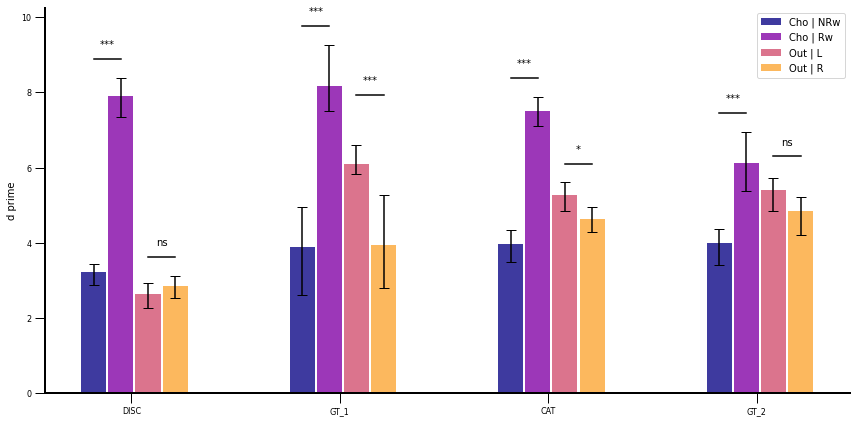

In [13]:
def compute_dprime(signal1,signal2):
    # print('mu1 ',np.mean(signal1))
    # print('mu2 ',np.mean(signal2))
    
    num = abs(np.mean(signal1) - np.mean(signal2))
    den = np.sqrt(0.5 * (np.var(signal1)+ np.var(signal2)))
    if num == 0:
        return 0
    elif den == 0:
        return np.inf
    else:
        return num / den
def compute_dprime_combinations(dataset):
    '''
    compute dprimes along dimensions given by axes for each combination
    '''
    axes=[1,2] # combination is expressed as cat, cho, out 
    dprime_combinations = []
    for i,axis in enumerate(axes):
        for j in range(2): # binary variables
            split_dataset = []
            for key in dataset:
                if np.array(key)[axes[1-i]] == j:
                    split_dataset.append(dataset[key])
            split_dataset = np.concatenate(split_dataset)
            
            clouds = [[],[]]
            for datapoint in split_dataset:
                if datapoint[i] < 0:
                    clouds[0].append(datapoint[i])
                else:
                    clouds[1].append(datapoint[i])
            
            dprime_combinations.append(compute_dprime(clouds[0],clouds[1]))
            
    return dprime_combinations

def bar_dprime(window_length=1):
    comparisons = [[0,1],[2,3]]
    nr_samples = 20 # max 20 stored in table
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    phase_labels = ['DISC','GT_1','CAT','GT_2']
    window = 'post_choice'
    bar_labels = ['Cho | NRw', 'Cho | Rw', 'Out | L', 'Out | R']
    colors = plt.cm.plasma(np.linspace(0,0.8,len(bar_labels)))
    p_values = {}
    dprimes = np.zeros((len(phases),len(bar_labels),nr_samples))
    for i,phase in enumerate(phases):
        p_values[phase] = {}
        print('PHASE: ',phase)
        entry = Window_cohort_decspace() & 'experimental_timepoint="%s"'%phase \
                & 'window="%s"'%window \
                    & 'window_length="%s"'%window_length
                    
        # acc shape  nr vars
        accuracy = np.array(entry.fetch('accuracy')[0])
        # excluding related category term
        print('accuracy: ',accuracy[1:])
        # ccgp shape  nr vars x nr cross vars
        ccgp = np.array(entry.fetch('ccgp')[0])[:,1]
        print('ccgp: ',ccgp[1:])
        x_test =  np.array(entry.fetch('x_test')[0])
        # nr runs x nr vars x nr neurons 
        dec_vecs = np.array(entry.fetch('decoder_vec')[0])
        combinations = entry.fetch('combinations')[0]
        
        nr_states = len(combinations)
        nr_runs = x_test.shape[0]
        nr_neurons = x_test.shape[-1]
        nr_trials = x_test.shape[-2]
        assert nr_trials % nr_states == 0
        nr_trials_state = int(nr_trials / nr_states)
                    
        for idx in range(nr_runs):
            proj_dims = dec_vecs[idx,1:]
            assert proj_dims.shape[-1] == nr_neurons #  choice and outcome
            dataset = dict() #states x (mu, std) x (cho, out) 
            for s in range(nr_states):
                # nr runs x nr conditions*nr trials x nr neurons 
                trial_idx = s * nr_trials_state
                data_state = x_test[idx,trial_idx:trial_idx+nr_trials_state]
                # project onto decoder plane
                dataset[combinations[s]] = data_state.dot(proj_dims.T)
            # compute d prime along one axis on a subset - all combinations cho x out
            dprimes[i,:,idx] = compute_dprime_combinations(dataset)
        
        # compute statistical significance
        for c,comparison in enumerate(comparisons):
            col1,col2 = comparison
            
            normality = True
            for k in range(2):
                try:
                    normality = normality_test(dprimes[i,comparison[k],:])
                except:
                    pass
                if not normality:
                    break
                
            if normality:
                result = ttest_rel(dprimes[i,col1],dprimes[i,col2],alternative="two-sided")
                test = 'Paired t-test'
            else:
                result = wilcoxon(dprimes[i,col1],dprimes[i,col2],alternative="two-sided")
                test = 'Wilcoxon signed rank test'
            p_value = result.pvalue
            print(test)
            print('%s vs %s: '%(bar_labels[col1],bar_labels[col2]),p_value)
            p_values[phase][(col1,col2)] = p_value
                          
    # Calculate means and IQR for error bars
    # means  nr phases x nr columns
    means = np.mean(dprimes,axis=2)
    q25 = np.percentile(dprimes,25,axis=2)
    q75 = np.percentile(dprimes,75,axis=2)
    errors = np.array([means - q25, q75 - means])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.12
    spacing = 0.01
    index = np.arange(len(phases))
    
    # Plot bars and error bars
    for i, attr in enumerate(bar_labels):
        x_pos = index + (bar_width + spacing) * i
        ax.bar(x_pos, means[:, i], bar_width, 
                      yerr=errors[:, :, i], 
                      label=attr, 
                      capsize=5,color= colors[i],
                      alpha=0.8)
    
    # Customize the plot
    ax.set_ylabel('d prime')
    ax.set_xticks(index + bar_width * 1.5)
    ax.set_xticklabels(phase_labels)
    ax.legend()
    ax = format_axs(ax)
    # Add statistical annotations
    def add_stat_annotation(ax, phase_idx, attr1_idx, attr2_idx, p_val):
        x1 = phase_idx + (bar_width + spacing) * attr1_idx
        x2 = phase_idx + (bar_width + spacing) * attr2_idx
        y_max = max(means[phase_idx, attr1_idx], means[phase_idx, attr2_idx])
        y_pos = y_max + errors[1][phase_idx, max(attr1_idx, attr2_idx)] + 0.5
        
        ax.plot([x1, x2], [y_pos, y_pos], 
                lw=1.5, c='black')
        ax.text((x1 + x2) * 0.5, y_pos + 0.25, 
                p_to_ast(p_val), 
                ha='center', va='bottom')
    
    # Add significant p-values (p < 0.05)
    for p_idx, phase in enumerate(phases):
        for pair, p_val in p_values[phase].items():
            attr1_idx,attr2_idx = pair
            add_stat_annotation(ax, p_idx, attr1_idx, attr2_idx, p_val)
    
    plt.tight_layout()
    plt.show()

bar_dprime()  

## Fig 6G
### Rectangularity index as computed in the projected neural state space for decoding dimensions of choice and outcome

PHASE:  discrimination
accuracy:  [0.91732615 0.73367872]
ccgp:  [0.72383345 0.63171766]
PHASE:  gentest_1
accuracy:  [0.94790334 0.90059805]
ccgp:  [0.86494263 0.77904381]
PHASE:  categorization_4
accuracy:  [0.96415508 0.96815021]
ccgp:  [0.83085362 0.80917246]
PHASE:  gentest_2
accuracy:  [0.96259736 0.95913421]
ccgp:  [0.89486787 0.84430459]
One way Anova test
p: 1.8882767306079868e-07


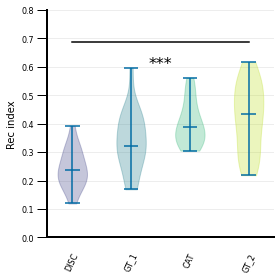

In [15]:
def compute_rectangularity(dataset):
    # computes rectangularity index for 2d shapes
    
    # compute means of states in x y coordinates
    mean_states = np.zeros((len(dataset),2))
    for k,state in enumerate(dataset):
        assert dataset[state].shape[-1] == 2
        mean_states[k] = np.mean(dataset[state],axis=0)
        
    # sort from low to high x
    sorted_idx = np.argsort(mean_states[:, 0])
    mean_states = mean_states[sorted_idx]
    
    # side lengths
    side_vectors = []
    side_lengths = []
    for l in range(1,4):
        side_vector = mean_states[l]-mean_states[l-1]
        side_lengths.append(np.linalg.norm(side_vector))
        side_vectors.append(side_vector)
        
    # last side vector
    side_vector = mean_states[0]-mean_states[3]
    side_vectors.append(side_vector) 
    side_lengths.append(np.linalg.norm(side_vector))
    
    # compute angles
    cos_angles = []
    for l in range(1,4):
        cos_angle = np.dot(side_vectors[l-1],side_vectors[l]) / (side_lengths[l]*side_lengths[l-1])
        cos_angles.append(abs(cos_angle))
    
     
    cos_angle = np.dot(side_vectors[3],side_vectors[0]) / (side_lengths[0]*side_lengths[3])
    cos_angles.append(abs(cos_angle))
    
    # index
    l1 = np.min([side_lengths[0],side_lengths[2]]) / np.max([side_lengths[0],side_lengths[2]])
    l2 = np.min([side_lengths[1],side_lengths[3]]) / np.max([side_lengths[1],side_lengths[3]])
    rec_index = ((l1 + l2) / 2 ) * (1 - np.mean(cos_angles))
    
    return rec_index

def plot_rectangularity_index(window_length=1):
        
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    phase_labels = ['DISC','GT_1','CAT','GT_2']
    window = 'post_choice'
    nr_samples = 20 
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    fig,axs  = plt.subplots()
    fig.set_figheight(4)
    fig.set_figwidth(4)
    rectangularity = np.zeros((nr_samples,len(phases)))
    
    for i,phase in enumerate(phases):
        print('PHASE: ',phase)
        entry = Window_cohort_decspace() & 'experimental_timepoint="%s"'%phase \
                & 'window="%s"'%window \
                    & 'window_length="%s"'%window_length
                    
        # acc shape  nr vars
        accuracy = np.array(entry.fetch('accuracy')[0])
        # excluding related category term
        print('accuracy: ',accuracy[1:])
        # ccgp shape  nr vars x nr cross vars
        ccgp = np.array(entry.fetch('ccgp')[0])[:,1]
        print('ccgp: ',ccgp[1:])
        x_test =  np.array(entry.fetch('x_test')[0])
        # nr runs x nr vars x nr neurons 
        dec_vecs = np.array(entry.fetch('decoder_vec')[0])
        combinations = entry.fetch('combinations')[0]
        
        nr_states = len(combinations)
        nr_runs = x_test.shape[0]
        assert nr_runs == nr_samples
        nr_neurons = x_test.shape[-1]
        nr_trials = x_test.shape[-2]
        assert nr_trials % nr_states == 0
        nr_trials_state = int(nr_trials / nr_states)
            
        
        for j,idx in enumerate(range(nr_runs)): 
            proj_dims = dec_vecs[idx,1:]
            assert proj_dims.shape[-1] == nr_neurons #  choice and outcome
            dataset = dict() #states x nr trials x nr dims
            for s in range(nr_states):
                # nr runs x nr conditions*nr trials x nr neurons 
                trial_idx = s * nr_trials_state
                data_state = x_test[idx,trial_idx:trial_idx+nr_trials_state]
                # project onto decoder plane
                dataset[combinations[s]] = data_state.dot(proj_dims.T)
                
            rectangularity[j,i] = compute_rectangularity(dataset)
            
    # datapoints are nr samples x nr columns/conditions
    axs = format_violinplot(axs,rectangularity,phase_labels,
                            colors=colors,y_label='Rec index')
    axs = format_axs(axs)
    axs.set_ylim(0,0.8)
    
    # statistical test changes across phases
    
    homogeneity = True
    res = levene(rectangularity[:,0],
               rectangularity[:,1],
               rectangularity[:,2],
               rectangularity[:,3])
    if res.pvalue < 0.05:
        homogeneity = False
        
    test = 'One way Anova' # one factor stage, with four levels

    # check normality
    normality = True
    for j,phase in enumerate(phases):
        shapiro_test = shapiro(rectangularity[:,j])
        
        if shapiro_test.pvalue < 0.05:
            normality = False
            break
        
    if normality and homogeneity:
        test = 'One way Anova test'
    else:
        test = 'Kruskall-Wallis test'
    
    print(test)
    
    if normality and homogeneity:
        # one way anova
        res = stats.f_oneway(rectangularity[:,0],
               rectangularity[:,1],
               rectangularity[:,2],
               rectangularity[:,3])
        pval = res.pvalue
        
        # # transform data to pandas dataframe
        data = np.concatenate(rectangularity)
        stage_col = np.repeat(np.arange(len(phases)),nr_samples)
        data_df = np.vstack((data,stage_col)).T
        df = pd.DataFrame(data_df, columns=['auc', 'stage'])

        # check normality of residues of model
        model = ols('auc ~ C(stage)-1', data=df).fit()
        
        # model.pvalue,   model.model.exog_names
        _,resid_pval = shapiro(model.resid)
        #print('normality residue: ',resid_pval>0.05)
        
        
    else:
        # kruskal wallis
        res = stats.kruskal(rectangularity[:,0],
               rectangularity[:,1],
               rectangularity[:,2],
               rectangularity[:,3])
        pval = res.pvalue
        
    print('p: %s'%str(pval))
    ymax = rectangularity.max(); ymin = rectangularity.min()
    axs = statistical_annotation(axs,[[0,3]],[pval],ymax,ymin)

    plt.tight_layout()
    plt.show()

plot_rectangularity_index()

## Fig 6H & 6I
### Forest plot of predictor coefficient values (log scale) of binomial regression model (after model selection) with 95% confidence interval. Interaction effect plot  $Cc-cho_{out}$ : $ Cc-out_{cho}$

Discard models with multicollinearity in regressors. Selection of model by minimizing BIC

In [8]:
def select_model(window_length=1,window='post_choice'):
    window = 'post_choice'
    all_models = Bin_nrl_to_beh() & 'cov_type="HC3"' \
            & 'window="%s"'%window & 'window_length>"%s"'%str(window_length -0.1) \
                & 'window_length<"%s"'%str(window_length +0.1) # \
            
    
    # no multicollinearity vif < 10
    all_models = all_models & 'collinear_bool="0"'
    
    # Likelihood ratio test - for nested models
    # against null model
    all_models = all_models & 'lrt_null<"0.05"'
    # demonstrate value of added term - justify interaction term
    all_models = all_models & 'lrt_reduced<"0.05"'
    
    # present table with models
    properties = ['run_id','bic','deviance_explained','deviance_ratio',
                  'mse_ratio','mse_ratio_std','formula','nr_outliers']
    
    model_selection = dict()
    for prop in properties:
        model_selection[prop] = []
    
     
    for model in all_models:
        for prop in properties:
            if prop in model.keys():
                model_selection[prop].append(model[prop])
            else:
                if prop == 'nr_outliers':
                    if model['outliers'] is not None:
                        model_selection[prop].append(len(model['outliers']))
                    else:
                        model_selection[prop].append(0)
               
    model_selection = pd.DataFrame.from_dict(model_selection)

    # bic lower the better - deviance explained the higher the better
    model_selection = model_selection.sort_values(by='bic')
    
    return model_selection

select_model()


,run_id,bic,deviance_explained,deviance_ratio,mse_ratio,mse_ratio_std,formula,nr_outliers
2,64,134.901,62.3936,0.891004,2.812760,0.841231,Corr + Incorr ~ C(St_id) + Cc_cho + Cc_out + C...,0
3,65,149.237,58.9045,1.412060,2.741940,0.783552,Corr + Incorr ~ C(St_id) + Cc_cho + Cc_out + C...,1
0,56,149.737,38.4240,2.143750,0.473789,0.339419,Corr + Incorr ~ Cc_cho + Cc_out + Cc_cho:Cc_out,0
1,57,166.436,32.4321,2.647400,0.648865,0.427524,Corr + Incorr ~ Cc_cho + Cc_out + Cc_cho:Cc_out,1


Models with run_id 64 and 65 correspond to the same model formula. However, run_id=64 runs without outliers and run_id=65 is the full dataset. We therefore pick the model without discarding any datapoint as our selected model and use run_id=64 as an extra analysis.

In [10]:
selected_model = Bin_nrl_to_beh() & 'run_id="65"'
selected_model.fetch('formula')[0]

'Corr + Incorr ~ C(St_id) + Cc_cho + Cc_out + Cc_cho:Cc_out'

In [30]:
selected_model.fetch('bic')[0]

149.237

In [31]:
selected_model.fetch('llf')[0]

-63.7999

In [32]:
selected_model.fetch('nr_datapoints')[0]

22

In [33]:
selected_model.fetch('df_model')[0]

6

In [34]:
selected_model.fetch('reg_names')[0]

['Intercept',
 'C(St_id)[T.discrimination]',
 'C(St_id)[T.gentest_1]',
 'C(St_id)[T.gentest_2]',
 'Cc_cho',
 'Cc_out',
 'Cc_cho:Cc_out']

In [35]:
selected_model.fetch('coefs')[0]

[1.1278897586224674,
 0.2496893283377299,
 -0.3685234078475002,
 -0.2859175491836362,
 -0.15556577385524395,
 -0.06601516640614605,
 0.175436391160256]

In [36]:
selected_model.fetch('pvalues')[0]

[2.5248010328497594e-22,
 0.07033649261702878,
 0.005783743243207901,
 0.04451552389043949,
 0.0008627258813770829,
 0.2555720257184523,
 4.2477002543680544e-05]

In [37]:
selected_model.fetch('deviance_explained')[0]

58.9045

In [38]:
selected_model.fetch('lrt_reduced')[0]

0.000130457

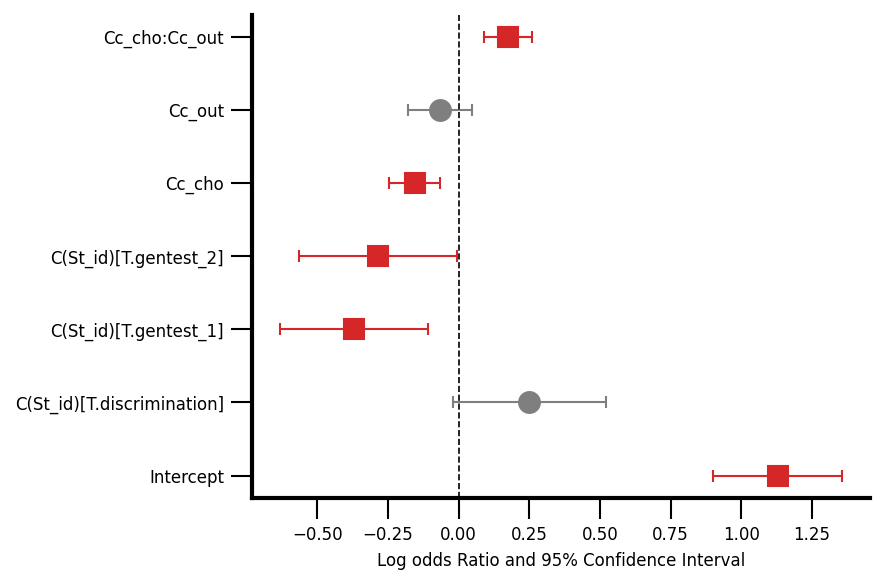

In [14]:
def forest_plot(model_entry):
    reg_names = model_entry.fetch('reg_names')[0]
    coefs = model_entry.fetch('coefs')[0]
    pvalues = model_entry.fetch('pvalues')[0]
    conf_int = np.array(model_entry.fetch('conf_int')[0])
    
    # forest plot
    fig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(6, 4), dpi=150)
    for idx, reg in enumerate(reg_names):
        ci = [[coefs[idx] - conf_int[0,idx]], [conf_int[1,idx] - coefs[idx]]]
        if pvalues[idx] < 0.05: # significant
            plt.errorbar(x=[coefs[idx]], y=[reg], xerr=ci,
                ecolor='tab:red', capsize=3, linestyle='None', linewidth=1, marker="s", 
                          markersize=10, mfc="tab:red", mec="tab:red")
        else:
            plt.errorbar(x=[coefs[idx]], y=[reg], xerr=ci,
                ecolor='tab:gray', capsize=3, linestyle='None', linewidth=1, marker="o", 
                          markersize=10, mfc="tab:gray", mec="tab:gray")
            
    ax = format_axs(ax)
    plt.axvline(x=0, linewidth=0.8, linestyle='--', color='black')
    plt.tick_params(axis='both', which='major', labelsize=8)
    plt.xlabel('Log odds Ratio and 95% Confidence Interval', fontsize=8)
    plt.tight_layout()
    plt.show()
    
forest_plot(selected_model)

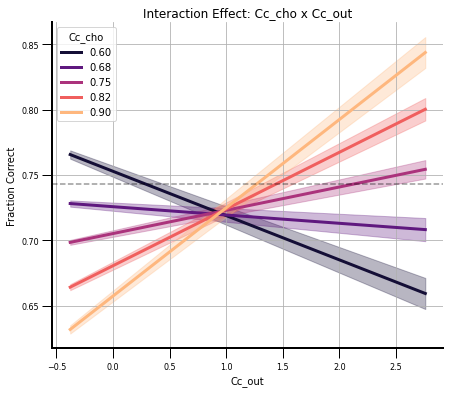

In [15]:
def get_bin_nrl_dataset(window='post_choice',window_length=1):
    event_align = 'choice'
    animal_ids = ['BK4926_L',
     'BK4933_LR',
     'BK4936_L',
     'BK4937_R',
     'BK4947_R',
     'BK4956_LR']
    
    columns = ['Animal_id','St_id','Corr','Incorr',
               'Cc_out','Cc_cho','Ps_cho',
               'Ps_out']
    
    data = {}
    for col in columns:
        data[col] = []
    phases = [
        'discrimination',
        'gentest_1',
        'categorization_4',
        'gentest_2'
        ]
        
    for i,phase in enumerate(phases):
            
        mode,stage,categoryset_id = trainingpoint_dict[phase]
        
        for animal_id in animal_ids:
            # print('animal_id: ',animal_id)
            entry = Window_subject_decoder()\
                       & 'experimental_timepoint="%s"'%phase \
                           & 'event_align="%s"'%event_align & 'trace_type="dff"' \
                               & 'window="%s"'%window & 'window_length>="%s"'%str(window_length - 0.1)\
                                       & 'window_length<"%s"'%str(window_length + 0.1) \
                                   & 'animal_id="%s"'%animal_id
    
            if len(entry) !=0:
                session_ids = entry.fetch('session_ids')[0]
                # print('session_ids',session_ids)
                session_id = session_ids[0]
                ccgp = np.array(entry.fetch('ccgp')[0])
                ps = np.array(entry.fetch('ps')[0])
                # gather neural parameters
                cc_cho = np.mean(ccgp,0)[1,1]
                cc_out = np.mean(ccgp,0)[2,1]
                ps_cho = np.cos(np.deg2rad(np.mean(ps,0)[1,1]))
                ps_out = np.cos(np.deg2rad(np.mean(ps,0)[2,1]))

                
                # gather performance parameters
                
                total_trials = 0
                corr_trials = 0
                for session_id in session_ids:
                    
                    trial_entries = Trial() \
                      & 'mode="%s"'%mode & 'stage="%s"'%stage \
                          & 'categoryset_id="%s"'%categoryset_id \
                              & 'animal_id="%s"'%animal_id \
                                  & 'session_id="%i"'%session_id
                                  
                    valid = trial_entries & 'trialtype="active"' \
                         & 'responsetype!="no response"' 
                         
                    total_trials += len(valid)
                    correct = valid & 'responsetype="correct"' 
                    
                    corr_trials += len(correct)
        
                incorr_trials = total_trials - corr_trials

                data['Animal_id'].append(animal_id)
                data['St_id'].append(phase)
                data['Corr'].append(corr_trials)
                data['Incorr'].append(incorr_trials)
                data['Cc_out'].append(cc_out)
                data['Cc_cho'].append(cc_cho)
                data['Ps_out'].append(ps_out)
                data['Ps_cho'].append(ps_cho)
        
    
    data = pd.DataFrame.from_dict(data)
    data['Total'] = data['Corr'] + data['Incorr']
    data['Fr_corr'] = data['Corr'] / data['Total']
    data['Cc_out_raw'] = data['Cc_out'] 
    data['Cc_cho_raw'] = data['Cc_cho'] 
    # standardize 
    data['Cc_out'] = (data['Cc_out'] - data['Cc_out'].mean()) / data['Cc_out'].std()
    data['Cc_cho'] = (data['Cc_cho'] - data['Cc_cho'].mean()) / data['Cc_cho'].std()
    
    return data

def interaction_effect_plot(model_entry):
    
    experiment = model_entry.fetch('name')[0]
    window = model_entry.fetch('window')[0]
    window_length = model_entry.fetch('window_length')[0]
    formula = model_entry.fetch('formula')[0]
    cov_type = model_entry.fetch('cov_type')[0]
    
    reg_terms = formula.split(' ~ ')[1]
    if '-' in formula:
        reg_terms = reg_terms.split(' - ')[0]
    regs = reg_terms.split(' + ')
    cat_regs = [reg[2:-1] for reg in regs if 'C(' in reg]
    int_reg = [reg for reg in regs if ':' in reg][0]
    reg1, reg2 = int_reg.split(':')
    
    if ':' not in formula:
        return 'No interaction term in formula. Cannot plot interaction contour plot'
    
    data = get_bin_nrl_dataset(window,window_length)
    
    binom_model = sm.GLM.from_formula(formula=formula, family=sm.families.Binomial(), data=data)
    if cov_type is None:
        binom_model_results = binom_model.fit()
    else:
        binom_model_results = binom_model.fit(cov_type='HC3')

        
    # Create a grid for Cc_cho and Cc_out
    reg1_vals_raw = np.linspace(0.6,0.9,5) 
    reg2_vals_raw = np.arange(0.6,0.9,0.015) 
    if '_raw' not in reg1:
        m1 = data[reg1 + '_raw'].mean()
        st1 = data[reg1 + '_raw'].std()
        m2 = data[reg2 + '_raw'].mean()
        st2 = data[reg2 + '_raw'].std()
        
        reg1_vals =  (reg1_vals_raw - m1)/st1
        reg2_vals = (reg2_vals_raw - m2)/st2
        
    else:
        reg1_vals = reg1_vals_raw
        reg2_vals = reg2_vals_raw
       
    pred_data = pd.DataFrame()
    pred_data[reg2] = reg2_vals
    nr_datapoints = len(pred_data)
        
    all_lines = []
    for n in range(100):
        lines = []
        for val1 in reg1_vals:
            temp_data = pred_data.copy()
            temp_data[reg1] = val1
            # predict categorical variables
            for reg in cat_regs:
                levels = sorted(data[reg].unique())
                # generate random datapoints of levels in variable
                temp_data[reg] = np.random.choice(levels,size=nr_datapoints)
            
            preds = binom_model_results.predict(temp_data)
           
            lines.append(preds)
            
        all_lines.append(lines)
        
    lines = np.mean(all_lines,0)
        
    # Plot
    fig,axs = plt.subplots()
    fig.set_figheight(6)
    fig.set_figwidth(7)
    
    colors = plt.cm.magma(np.linspace(0.1,0.85,len(lines)))
    x = reg2_vals
    # create line plots 
    for i, preds in enumerate(lines):
        coefficients, cov = np.polyfit(x, preds, deg=1, cov=True)
        slope, intercept = coefficients
        slope_err, intercept_err = np.sqrt(np.diag(cov))
        y = slope * x + intercept
        # 95 % CI - +- 1.96 std error
        y_upper = (slope + 1.96*slope_err) * x + (intercept + 1.96*intercept_err)
        y_lower = (slope - 1.96*slope_err) * x + (intercept - 1.96*intercept_err)
        
        axs.plot(x, y, 
                    label = f'{reg1_vals_raw[i]:.2f}',
                    color=colors[i],
                    linewidth=3)
        axs.fill_between(x, y_lower,y_upper, color=colors[i], 
                                  alpha=0.3)
    
    axs = format_axs(axs)
    axs.axhline(np.mean(data['Fr_corr']),linestyle='--',color='black',alpha=0.4)
    axs.set_xlabel(reg2)
    axs.set_ylabel('Fraction Correct') 
    axs.set_title(f'Interaction Effect: {reg1} x {reg2}') 

    axs.legend(title=f'{reg1}') 
    plt.grid(True) 
    plt.show()
    
interaction_effect_plot(selected_model)